In [1]:
import pandas as pd
import seaborn as sns

In [2]:
data = pd.read_csv("Churn_Modelling.csv")

In [3]:
data.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


# Handling Missing Values


In [4]:
data.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
data.shape

(10000, 14)

##### no missing vlaues detected

In [6]:
data.isnull().mean()

RowNumber          0.0
CustomerId         0.0
Surname            0.0
CreditScore        0.0
Geography          0.0
Gender             0.0
Age                0.0
Tenure             0.0
Balance            0.0
NumOfProducts      0.0
HasCrCard          0.0
IsActiveMember     0.0
EstimatedSalary    0.0
Exited             0.0
dtype: float64

In [7]:
data.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [8]:
# splitting 
X = data.drop(["Exited","RowNumber","CustomerId","Surname"],axis=1)
y = data["Exited"]

##### Note: 
##### Exicted = 1 ==> customer churned
##### Exicted = 0 ==> customer stayer

In [9]:
X.shape

(10000, 10)

# Train Test Split

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Engineering

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
cat_cols = ["Geography","Gender"]
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard','IsActiveMember', 'EstimatedSalary']

In [14]:
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols, dtype=int)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols, dtype=int)

X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns,fill_value=0)

In [15]:
X_train_encoded

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
9254,686,32,6,0.00,2,1,1,179093.26,1,0,0,0,1
1561,632,42,4,119624.60,2,1,1,195978.86,0,1,0,0,1
1670,559,24,3,114739.92,1,1,0,85891.02,0,0,1,0,1
6087,561,27,9,135637.00,1,1,0,153080.40,1,0,0,1,0
6669,517,56,9,142147.32,1,0,0,39488.04,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,768,54,8,69712.74,1,1,1,69381.05,1,0,0,0,1
5191,682,58,1,0.00,1,1,1,706.50,1,0,0,1,0
5390,735,38,1,0.00,3,0,0,92220.12,1,0,0,1,0
860,667,43,8,190227.46,1,1,0,97508.04,1,0,0,0,1


In [16]:
X_test_encoded

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
6252,596,32,3,96709.07,2,0,0,41788.37,0,1,0,0,1
4684,623,43,1,0.00,2,1,1,146379.30,1,0,0,0,1
1731,601,44,4,0.00,2,1,0,58561.31,0,0,1,1,0
4742,506,59,8,119152.10,2,1,1,170679.74,0,1,0,0,1
4521,560,27,7,124995.98,1,1,1,114669.79,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6412,602,53,5,98268.84,1,0,1,45038.29,0,1,0,1,0
8285,609,25,10,0.00,1,0,1,109895.16,1,0,0,0,1
7853,730,47,7,0.00,1,1,0,33373.26,1,0,0,1,0
1095,692,29,4,0.00,1,1,0,76755.99,1,0,0,0,1


In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

In [18]:
X_train_scaled

array([[ 0.35649971, -0.6557859 ,  0.34567966, ..., -0.57638802,
        -0.91324755,  0.91324755],
       [-0.20389777,  0.29493847, -0.3483691 , ..., -0.57638802,
        -0.91324755,  0.91324755],
       [-0.96147213, -1.41636539, -0.69539349, ...,  1.73494238,
        -0.91324755,  0.91324755],
       ...,
       [ 0.86500853, -0.08535128, -1.38944225, ..., -0.57638802,
         1.09499335, -1.09499335],
       [ 0.15932282,  0.3900109 ,  1.03972843, ..., -0.57638802,
        -0.91324755,  0.91324755],
       [ 0.47065475,  1.15059039, -1.38944225, ..., -0.57638802,
        -0.91324755,  0.91324755]], shape=(8000, 13))

## model training ~ using of classification models 

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

In [20]:
model1 = LogisticRegression(max_iter = 3000,class_weight="balanced")
model1.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [21]:
y_pred_lr = model1.predict(X_test_scaled)
y_pred_lr

array([1, 0, 1, ..., 1, 0, 0], shape=(2000,))

In [22]:
model2 = RandomForestClassifier(
    n_estimators=501,
    oob_score=True,
    max_depth=4,
    class_weight="balanced"
)
model2.fit(X_train_encoded, y_train)

,n_estimators,501
,criterion,'gini'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [23]:
y_pred_rf = model2.predict(X_test_encoded)

In [24]:
neg = (y_train == 0).sum()
pos= (y_train == 1).sum()

scale_pos = neg/pos
print(scale_pos)

3.8661800486618003


In [25]:
model3= XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight = scale_pos
)

model3.fit(X_train_encoded, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [26]:
y_pred_xgb = model3.predict(X_test_encoded)

In [27]:
model4 = SVC(
    kernel="rbf",
    C=1.0,
    probability=True,
    random_state=42,
    class_weight="balanced"
)

model4.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [28]:
y_pred_svc = model4.predict(X_test_scaled)

In [29]:
from sklearn.metrics import accuracy_score ,f1_score,classification_report

In [30]:
print("logistic regression testing accuracy: ", accuracy_score(y_test, y_pred_lr) * 100, "%")
print("Random Forest testing accuracy: ", accuracy_score(y_test, y_pred_rf) * 100, "%")
print("XG boost testing accuracy: ", accuracy_score(y_test, y_pred_xgb) * 100, "%")
print("svc testing accuracy: ", accuracy_score(y_test, y_pred_svc) * 100, "%")

logistic regression testing accuracy:  71.95 %
Random Forest testing accuracy:  79.14999999999999 %
XG boost testing accuracy:  81.39999999999999 %
svc testing accuracy:  78.45 %


In [31]:
y_pred_train_lr = model1.predict(X_train_scaled)
y_pred_train_rf = model2.predict(X_train_encoded)
y_pred_train_xgb = model3.predict(X_train_encoded)
y_pred_train_svc = model4.predict(X_train_scaled)
print("logistic regression Training accuracy: ", accuracy_score(y_train, y_pred_train_lr)*100, "%")
print("Random forest Training accuracy: ", accuracy_score(y_train, y_pred_train_rf)*100, "%")
print("XG boost Training accuracy: ", accuracy_score(y_train, y_pred_train_xgb)*100, "%")
print("svc Training accuracy: ", accuracy_score(y_train, y_pred_train_svc)*100, "%")

logistic regression Training accuracy:  70.76249999999999 %
Random forest Training accuracy:  78.95 %
XG boost Training accuracy:  85.1 %
svc Training accuracy:  81.675 %


In [32]:
print("Logistic Regression classification report:\n",classification_report(y_test,y_pred_lr))

Logistic Regression classification report:
               precision    recall  f1-score   support

           0       0.91      0.72      0.81      1607
           1       0.38      0.71      0.50       393

    accuracy                           0.72      2000
   macro avg       0.65      0.72      0.65      2000
weighted avg       0.81      0.72      0.75      2000



In [33]:
print("Random forest classification report:\n",classification_report(y_test,y_pred_rf))

Random forest classification report:
               precision    recall  f1-score   support

           0       0.93      0.80      0.86      1607
           1       0.48      0.76      0.59       393

    accuracy                           0.79      2000
   macro avg       0.71      0.78      0.73      2000
weighted avg       0.84      0.79      0.81      2000



In [34]:
print("XB Boost classification report:\n",classification_report(y_test,y_pred_xgb))

XB Boost classification report:
               precision    recall  f1-score   support

           0       0.93      0.83      0.88      1607
           1       0.52      0.75      0.61       393

    accuracy                           0.81      2000
   macro avg       0.73      0.79      0.75      2000
weighted avg       0.85      0.81      0.83      2000



In [35]:
print("SVC classification report:\n",classification_report(y_test,y_pred_svc))

SVC classification report:
               precision    recall  f1-score   support

           0       0.93      0.79      0.86      1607
           1       0.47      0.75      0.58       393

    accuracy                           0.78      2000
   macro avg       0.70      0.77      0.72      2000
weighted avg       0.84      0.78      0.80      2000



In [36]:
import matplotlib.pyplot as plt

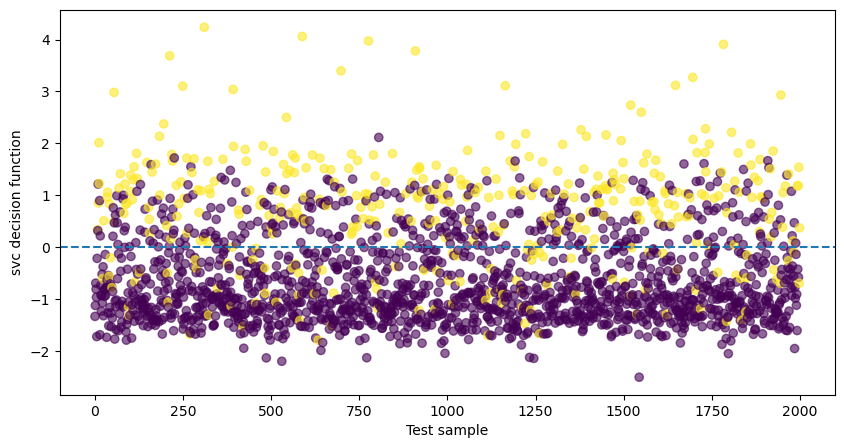

In [37]:
decision_scores = model4.decision_function(X_test_scaled)

plt.figure(figsize=(10,5))
plt.scatter(
    range(len(decision_scores)),
    decision_scores,
    c = y_test,
    alpha = 0.6
)

plt.axhline(0,linestyle="--")

plt.xlabel("Test sample")
plt.ylabel("svc decision function")
plt.show()

# handled overfitting of randomforest and xgboost
# handled class imbalance by class weights 

XG boost performed well then other:
test accuracy : 81%
churn recall : 75%
churn f1 : 61%